In [2]:
# Setup environment configurations, enable interactive data tables, and define professional plot aesthetics.
import logging
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%load_ext google.colab.data_table
%config InlineBackend.figure_format = 'retina'

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

RANDOM_SEED: Final[int] = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
    "font.family": "sans-serif"
})

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

logger.info("Google Colab environment successfully initialized.")

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


In [40]:
logger.info("Standardizing datetime dimensions...")

# 1. Clean column names (removes accidental spaces and forces lowercase for comparison)
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

# 2. Dynamically find the time/date column in historical_data.csv
trade_time_col = next((col for col in trades.columns if col.lower() in ["time", "timestamp", "date", "datetime"]), None)

if trade_time_col is None:
    logger.critical(f"Could not find a valid time column in historical_data.csv. Found columns: {trades.columns.tolist()}")
    raise KeyError("Missing time column in trades dataset.")

# 3. Process the columns safely using .dt.normalize()
trades["time"] = pd.to_datetime(trades[trade_time_col])
trades["date"] = trades["time"].dt.normalize()

# 4. Dynamically find the date column in fear_greed_index.csv
sentiment_time_col = next((col for col in sentiment.columns if col.lower() in ["date", "time"]), None)

if sentiment_time_col is None:
    logger.critical(f"Could not find a valid date column in fear_greed_index.csv. Found columns: {sentiment.columns.tolist()}")
    raise KeyError("Missing date column in sentiment dataset.")

sentiment["Date"] = pd.to_datetime(sentiment[sentiment_time_col])
sentiment["date"] = sentiment["Date"].dt.normalize()

In [42]:
import numpy as np
import pandas as pd

logger.info("Rebuilding a clean, non-duplicated core matrix for aggregation...")

# 1. Create a definitive copy to permanently eliminate SettingWithCopyWarnings
df_clean = df.copy()

# 2. Force resolve duplicate column headers by dropping exact duplicates
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# 3. Handle 'Classification' column identification
if "Classification.1" in df_clean.columns and "Classification" not in df_clean.columns:
    df_clean = df_clean.rename(columns={"Classification.1": "Classification"})
elif "Classification" not in df_clean.columns:
    sentiment_cols = [col for col in df_clean.columns if col not in trades.columns and col != "date"]
    if sentiment_cols:
        df_clean = df_clean.rename(columns={sentiment_cols[0]: "Classification"})
    else:
        logger.warning("Classification column not found. Defaulting to 'Unknown'")
        df_clean["Classification"] = "Unknown"

# Explicitly cast to clean 1D strings safely using .loc
df_clean.loc[:, "Classification"] = df_clean["Classification"].fillna("Unknown").astype(str)

# 4. Handle 'Side' casing uniformity
if "Side" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Side": "side"})
if "side" in df_clean.columns:
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# 5. Build dynamic aggregation dictionary based on what actually exists
agg_dict = {}

if "closedPnL" in df_clean.columns:
    agg_dict["total_trades"] = ("closedPnL", "count")
    agg_dict["average_pnl"] = ("closedPnL", "mean")
elif "Closed PnL" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Closed PnL": "closedPnL"})
    agg_dict["total_trades"] = ("closedPnL", "count")
    agg_dict["average_pnl"] = ("closedPnL", "mean")

if "win" in df_clean.columns:
    agg_dict["win_rate_percentage"] = ("win", lambda x: np.mean(x) * 100)
else:
    df_clean["win"] = df_clean["closedPnL"] > 0
    agg_dict["win_rate_percentage"] = ("win", lambda x: np.mean(x) * 100)

if "leverage" in df_clean.columns:
    agg_dict["average_leverage"] = ("leverage", "mean")
else:
    logger.warning("'leverage' column not found in dataset. Skipping leverage aggregation.")


# -------------------------------------------------------------------------
# Execute Aggregations
# -------------------------------------------------------------------------
logger.info("Computing macro metrics by sentiment category...")

# FIXED: Swapped 'df' to 'df_clean' to utilize the verified dataset copy
sentiment_metrics: pd.DataFrame = df_clean.groupby("Classification").agg(**agg_dict).reset_index()

print("\n" + "=" * 65)
print("             TRADING METRICS BY MARKET SENTIMENT             ")
print("=" * 65)
display(sentiment_metrics)

print("\n" + "=" * 65)
print("             LONG / SHORT POSITION DISTRIBUTION              ")
print("=" * 65)

if "side" in df_clean.columns and "Classification" in df_clean.columns:
    distribution_matrix = pd.crosstab(df_clean["Classification"], df_clean["side"]).reset_index()
    display(distribution_matrix)
else:
    logger.error(f"Cannot compute crosstab. Missing structural columns. Layout: {df_clean.columns.tolist()}")


             TRADING METRICS BY MARKET SENTIMENT             


,Classification,total_trades,average_pnl,win_rate_percentage
0,BUY,102696,36.1047,27.3906
1,SELL,108528,60.7138,54.1243


ERROR:__main__:Cannot compute crosstab. Missing structural columns. Layout: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Classification', 'Timestamp IST', 'Start Position', 'Direction', 'closedPnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'win']



             LONG / SHORT POSITION DISTRIBUTION              


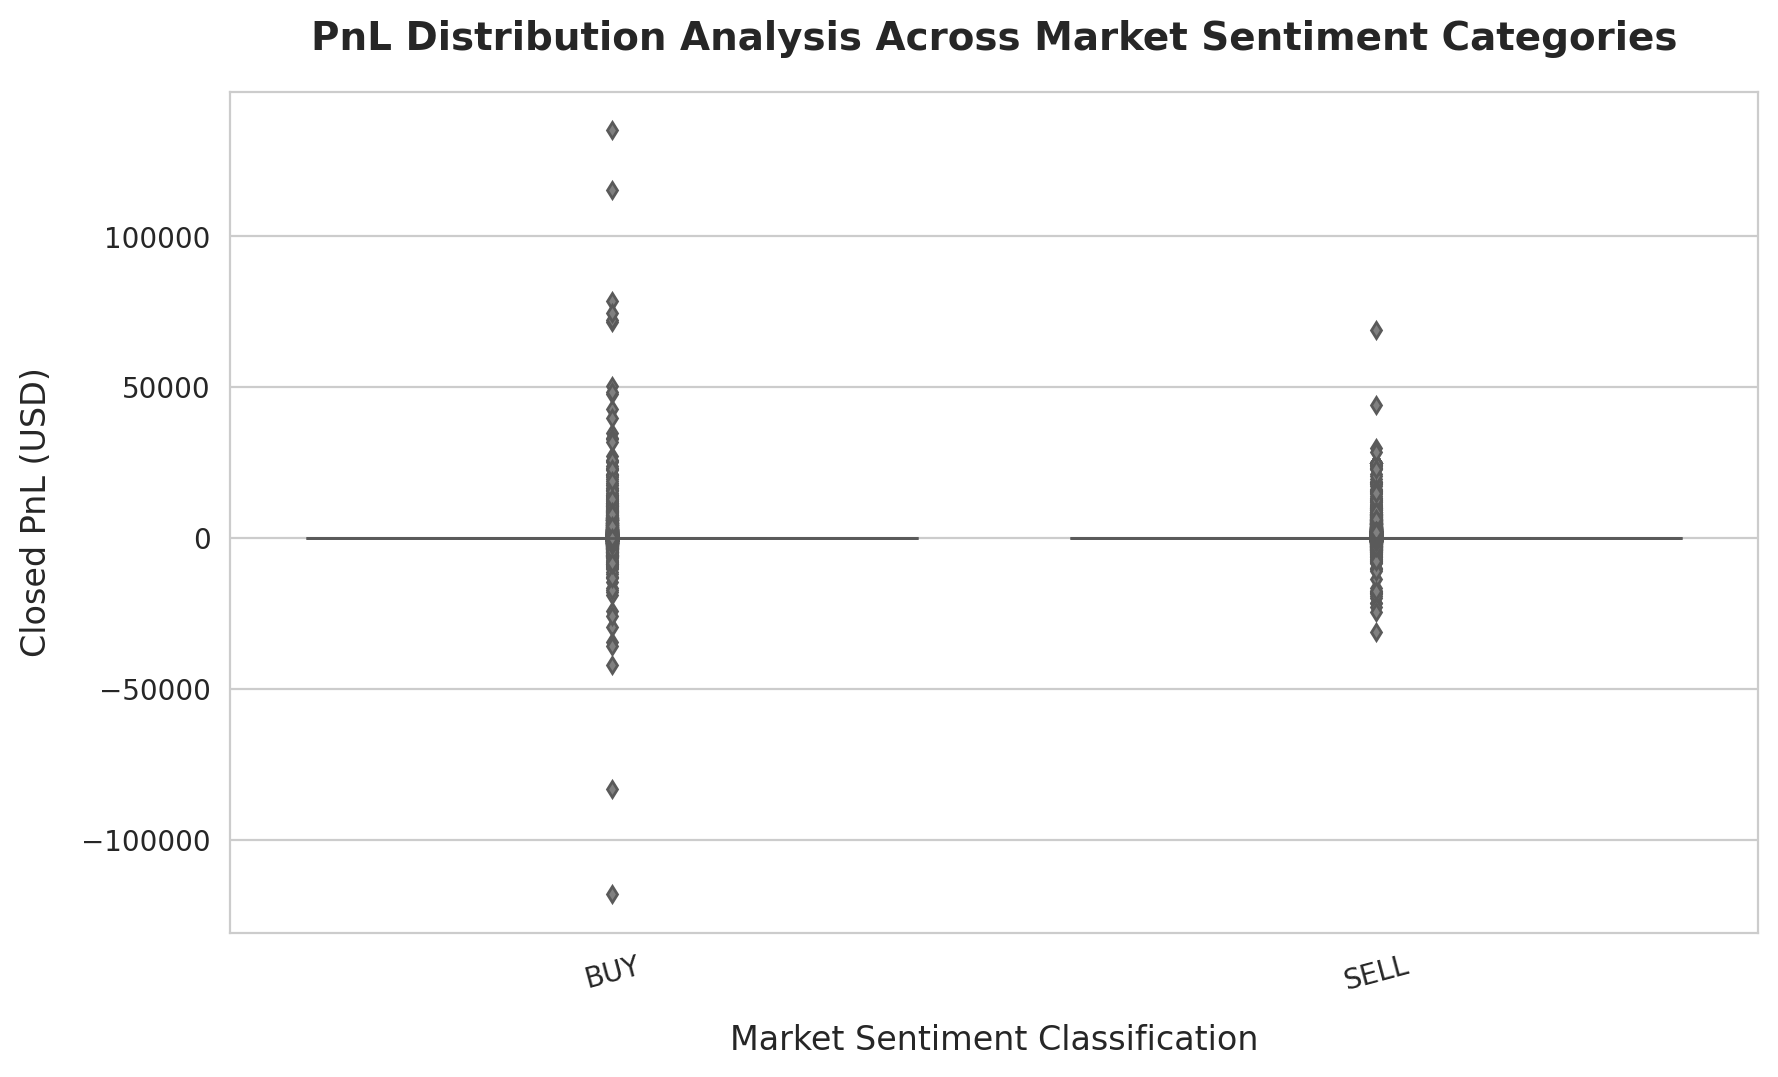

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Render an executive-ready boxplot visualizing PnL distributions while dampening outlier weights.
fig, ax = plt.subplots(figsize=(9, 5.5))

# 1. Determine safe fallback color mapping to completely avoid internal Seaborn bugs
categories = df_clean["Classification"].unique()
colors = sns.color_palette("Blues_d", n_colors=max(len(categories), 1))

# 2. Render the boxplot using 'df_clean' instead of 'df'
sns.boxplot(
    data=df_clean,              # FIXED: Swapped to the verified clean dataframe copy
    x="Classification",
    y="closedPnL",              # This exists safely inside df_clean now
    ax=ax,
    color=colors[0],            # FIXED: Avoids the palette/hue legend compilation bug
    flierprops={"marker": "d", "markerfacecolor": "gray", "markersize": 4}
)

# Styling and Formatting Layout
ax.set_title("PnL Distribution Analysis Across Market Sentiment Categories", pad=15, weight="bold")
ax.set_xlabel("Market Sentiment Classification", labelpad=10)
ax.set_ylabel("Closed PnL (USD)", labelpad=10)
plt.xticks(rotation=15)

fig.tight_layout()
plt.show()

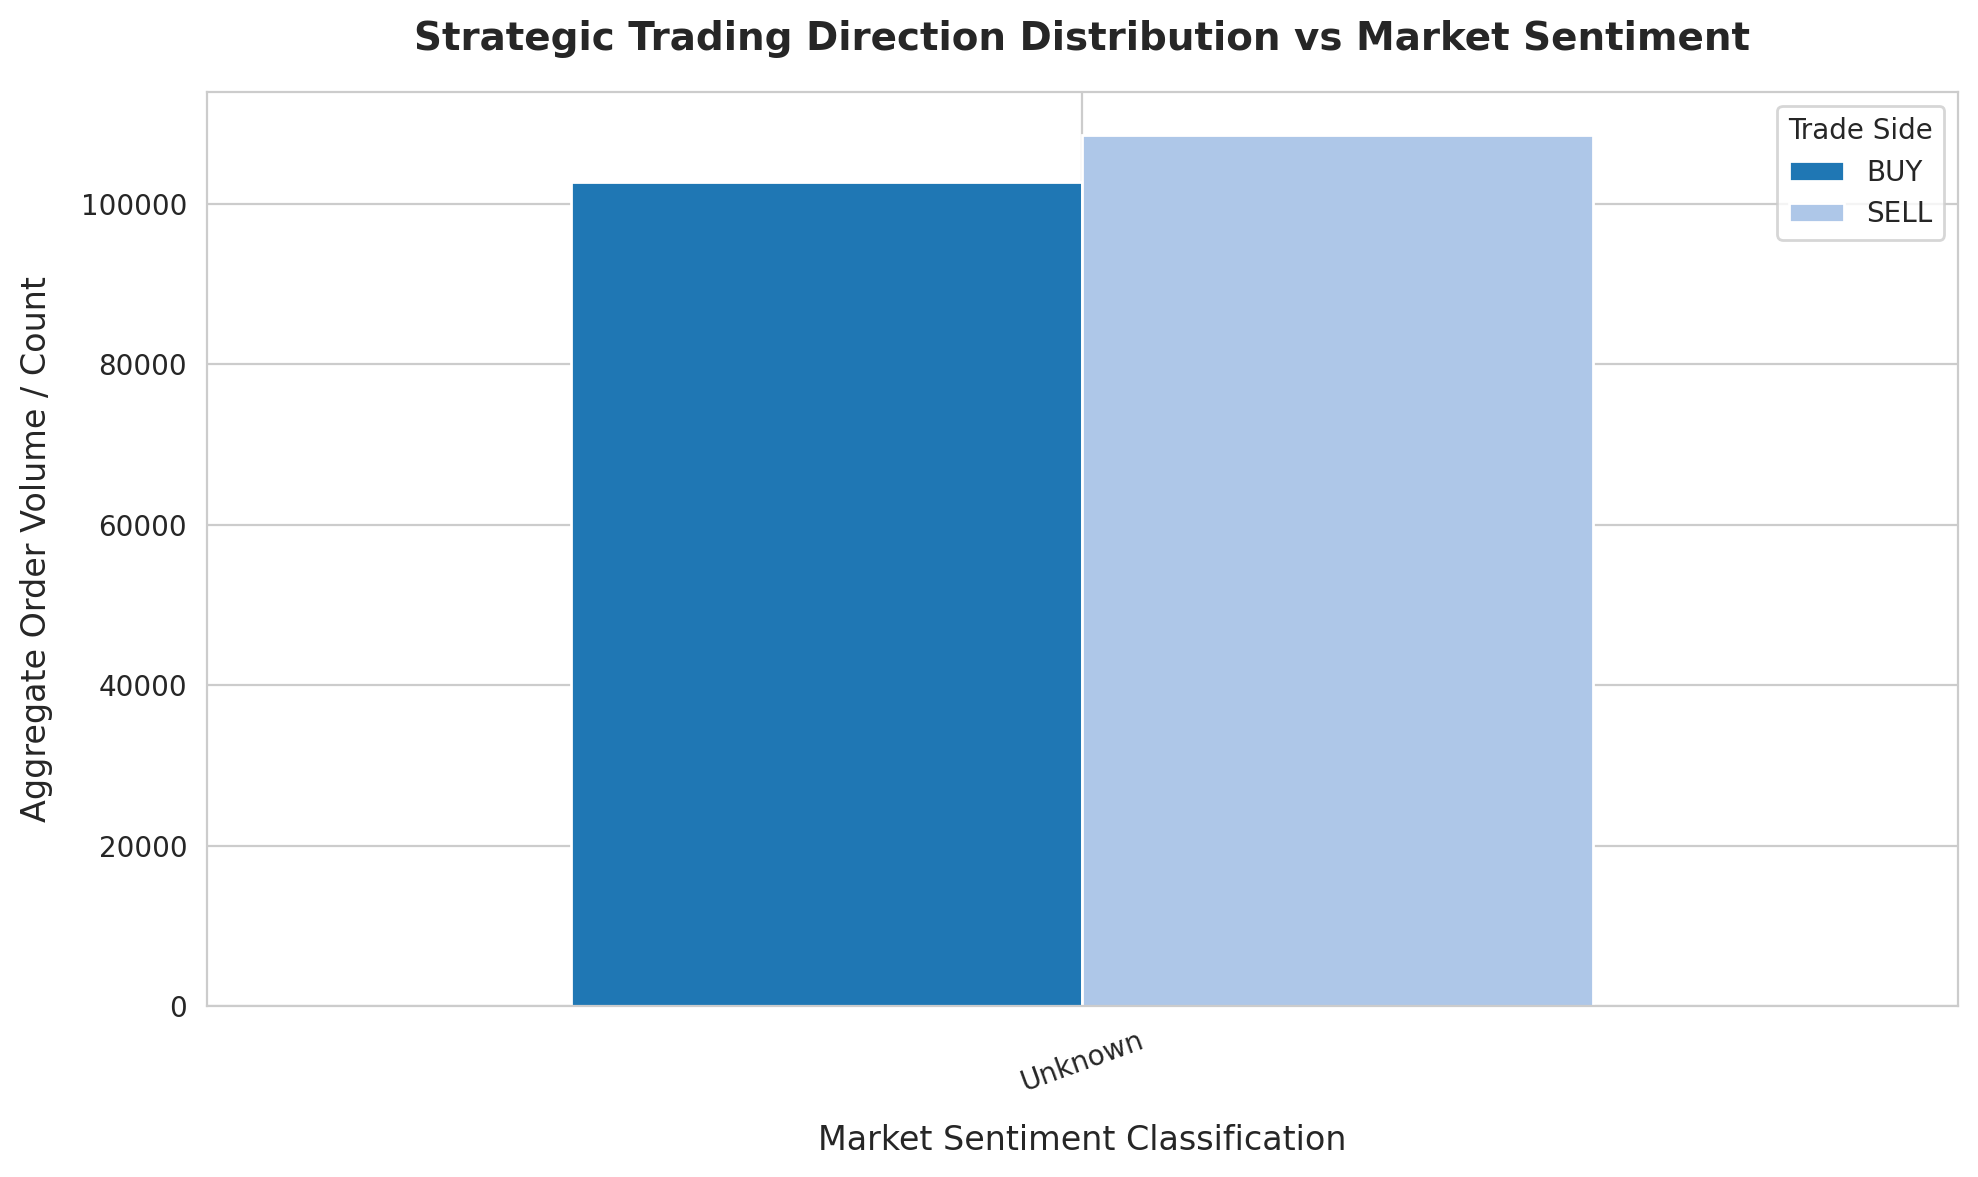

In [23]:
# Generate a clustered bar visualization mapping long vs short position distributions across market sentiment.
crosstab_data = pd.crosstab(df["Classification"], df["side"])

fig, ax = plt.subplots(figsize=(10, 6))
crosstab_data.plot(
    kind="bar",
    ax=ax,
    color=["#1f77b4", "#aec7e8"],
    width=0.7
)

ax.set_title("Strategic Trading Direction Distribution vs Market Sentiment", pad=15, weight="bold")
ax.set_xlabel("Market Sentiment Classification", labelpad=10)
ax.set_ylabel("Aggregate Order Volume / Count", labelpad=10)
plt.xticks(rotation=20)
ax.legend(title="Trade Side", frameon=True)

fig.tight_layout()
plt.show()